# POLO baseline

This notebook implements the POLO baseline from `polo_baseline_ceiling_only.tex` using the same RF CSI dataloader style as `tutorial_rf_bp.ipynb`.

The implementation is intentionally paper-faithful:

- use the phase-calibrated RF receivers as provided by the dataset;
- generate compact POLO-I / POLO-II candidates from wrapped differential carrier phases;
- score only those candidates with the compressed raw-IQ ML cost;
- refine the best candidate by bounded local optimization on the same ML cost.

The unknown is 2D `(x, y)` at known transmitter height, while receiver ranges are true 3D ranges.


In [ ]:
# Optional: uncomment when this Jupyter kernel misses dependencies.
# import sys
# !{sys.executable} -m pip install matplotlib numpy scipy requests xarray pyyaml h5netcdf h5py netCDF4

In [ ]:
from pathlib import Path
import importlib.util
import itertools
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares, minimize


def _iter_candidate_tutorial_dirs() -> list[Path]:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "tutorials", cwd / "processing" / "tutorials"]

    vscode_notebook = globals().get("__vsc_ipynb_file__")
    if vscode_notebook:
        notebook_dir = Path(vscode_notebook).resolve().parent
        candidates.extend(
            [
                notebook_dir,
                notebook_dir / "tutorials",
                notebook_dir / "processing" / "tutorials",
            ]
        )

    ancestor_dirs = [cwd]
    for parent in cwd.parents:
        if parent == Path("/"):
            break
        ancestor_dirs.append(parent)
        if len(ancestor_dirs) >= 3:
            break

    for ancestor in ancestor_dirs:
        candidates.extend([ancestor / "tutorials", ancestor / "processing" / "tutorials"])
        candidates.extend(ancestor.glob("*/processing/tutorials"))
        candidates.extend(ancestor.glob("*/*/processing/tutorials"))

    seen: set[Path] = set()
    ordered: list[Path] = []
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        ordered.append(resolved)
    return ordered


for candidate_dir in _iter_candidate_tutorial_dirs():
    if (candidate_dir / "csi_plot_utils.py").exists():
        NOTEBOOK_DIR = candidate_dir
        break
else:
    raise ImportError(
        "Could not locate csi_plot_utils.py. Tried these tutorial directories: "
        + ", ".join(str(path) for path in _iter_candidate_tutorial_dirs())
    )

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load utility module from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules["csi_plot_utils"] = csi
spec.loader.exec_module(csi)

C0 = 299_792_458.0

In [ ]:
EXPERIMENT_ID = "EXP009"
DATASET_PATH = None
FREQUENCY_HZ = 920e6
SELECTED_CYCLE_ID = None
TX_HEIGHT_M = None  # If None, initialized from selected cycle rover_z and reused as known constant.

# Phase-calibration switch copied from the RF backprojection tutorial style.
# POLO assumes calibrated phases; this reference calibration is a practical snapshot-level correction.
USE_REFERENCE_CALIBRATION = False
CALIBRATION_CYCLE_ID = 1  # If None and calibration is on, use the first available cycle.
CALIBRATION_TX_XY_M = None  # Optional tuple (x, y). If None, use rover_x/rover_y of CALIBRATION_CYCLE_ID.
CALIBRATION_REFERENCE_HOSTNAME = None  # Keep None for per-host calibration.
CALIBRATION_PATH_LOSS_EXPONENT = 2.0

# Search-domain switch.
# True: use the known physical measurement-area rectangle below.
# False: do not use TX positions; fall back to the receiver-layout envelope plus GRID_MARGIN_M.
KNOW_MEASUREMENT_AREA = True
MEASUREMENT_AREA_X_BOUNDS_M = (0.0, 7.9)
MEASUREMENT_AREA_Y_BOUNDS_M = (0.0, 4.1)

# Candidate generation and solver controls.
POLO_VARIANT = "POLO-II"  # "POLO-I" or "POLO-II"
POLO_II_PAIR_DISTANCE_THRESHOLD_M = 1.05
POLO_II_REFINE_ALL_RAW_CANDIDATES = True  # Debug-friendly all-refined mode described in the note.
ROOT_SEED_GRID_SHAPE = (7, 7)
HYPERBOLA_RESIDUAL_TOL_M = 0.03
CANDIDATE_MERGE_TOL_M = 0.05
MAX_BRANCH_PAIRS = None  # Optional cap for quick experiments; None keeps all physical branches.

GRID_MARGIN_M = 0.40
EVAL_NUM_CYCLES = 5


In [ ]:
ds, dataset_path = csi.open_dataset(experiment_id=EXPERIMENT_ID, dataset_path=DATASET_PATH)
antenna_positions = csi.load_antenna_positions()
available_cycles = csi.available_cycle_ids(ds, EXPERIMENT_ID)

if SELECTED_CYCLE_ID is None:
    if USE_REFERENCE_CALIBRATION and available_cycles.size > 1:
        SELECTED_CYCLE_ID = int(available_cycles[1])
    else:
        SELECTED_CYCLE_ID = int(available_cycles[0])
else:
    SELECTED_CYCLE_ID = int(SELECTED_CYCLE_ID)

selected_position = csi.cycle_position(ds, EXPERIMENT_ID, SELECTED_CYCLE_ID)
if TX_HEIGHT_M is None:
    TX_HEIGHT_M = float(selected_position["rover_z"])

wavelength_m = C0 / FREQUENCY_HZ

print(f"Loaded dataset: {dataset_path}")
print(f"Experiment: {EXPERIMENT_ID} | cycles with CSI: {available_cycles.size}")
print(f"Carrier frequency: {FREQUENCY_HZ/1e6:.1f} MHz | wavelength: {wavelength_m*100:.2f} cm")
print(f"Selected cycle: {SELECTED_CYCLE_ID}")
print(f"Known TX height used for 2D localization: z={TX_HEIGHT_M:.3f} m")
print(f"Receiver positions loaded: {len(antenna_positions)}")
print(f"Known measurement area: {KNOW_MEASUREMENT_AREA}")
print(f"Reference calibration enabled: {USE_REFERENCE_CALIBRATION}")
selected_position


Loaded dataset: /home/hxiong/project/ELLIIIT-dataset-26/results/csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009__EXP010__EXP011__EXP012.nc
Experiment: EXP009 | cycles with CSI: 1355
Carrier frequency: 920.0 MHz | wavelength: 32.59 cm
Selected cycle: 2
Known TX height used for 2D localization: z=0.749 m
Ceiling antenna z threshold: z >= 2.350 m | selected receivers: 42
Reference calibration enabled: True


{'experiment_id': 'EXP009',
 'cycle_id': 2,
 'position_available': True,
 'rover_x': 4.3088642578125,
 'rover_y': 1.9039422607421874,
 'rover_z': 0.7492421875,
 'csi_host_count': 42}

In [ ]:
def build_cycle_measurement(
    ds,
    experiment_id: str,
    cycle_id: int,
    antenna_positions: dict[str, np.ndarray],
):
    snapshot = csi.extract_csi_snapshot(
        ds,
        experiment_id,
        int(cycle_id),
        antenna_positions=antenna_positions,
    )

    antenna_xyz = np.column_stack(
        [
            snapshot["antenna_x"].values.astype(float),
            snapshot["antenna_y"].values.astype(float),
            snapshot["antenna_z"].values.astype(float),
        ]
    )
    y = snapshot["csi_real"].values.astype(float) + 1j * snapshot["csi_imag"].values.astype(float)
    hostnames = snapshot["hostname"].values.astype(str)

    valid = np.isfinite(antenna_xyz).all(axis=1) & np.isfinite(y.real) & np.isfinite(y.imag)
    if not np.any(valid):
        raise ValueError(f"No mapped CSI receivers for {experiment_id} cycle {cycle_id}.")
    return snapshot, antenna_xyz[valid], y[valid], hostnames[valid]


def build_search_domain(
    antenna_positions: dict[str, np.ndarray],
    know_measurement_area: bool,
    measurement_area_x_bounds_m: tuple[float, float],
    measurement_area_y_bounds_m: tuple[float, float],
    margin_m: float = 0.4,
):
    if know_measurement_area:
        x_bounds = tuple(float(v) for v in measurement_area_x_bounds_m)
        y_bounds = tuple(float(v) for v in measurement_area_y_bounds_m)
        if x_bounds[0] >= x_bounds[1] or y_bounds[0] >= y_bounds[1]:
            raise ValueError("Measurement-area bounds must be increasing (min, max) pairs.")
        return x_bounds, y_bounds, "known measurement-area bounds"

    # Unknown area fallback: use only receiver geometry, not TX trajectory labels.
    ant_xyz = np.asarray(list(antenna_positions.values()), dtype=float)
    ant_xyz = ant_xyz[np.isfinite(ant_xyz).all(axis=1)]
    if ant_xyz.size == 0:
        raise ValueError("No finite receiver positions are available to build a fallback search domain.")
    x_min = np.nanmin(ant_xyz[:, 0]) - margin_m
    x_max = np.nanmax(ant_xyz[:, 0]) + margin_m
    y_min = np.nanmin(ant_xyz[:, 1]) - margin_m
    y_max = np.nanmax(ant_xyz[:, 1]) + margin_m
    return (float(x_min), float(x_max)), (float(y_min), float(y_max)), "receiver-layout fallback bounds"


def steering_for_point(
    tx_x_m: float,
    tx_y_m: float,
    tx_z_m: float,
    antenna_xyz: np.ndarray,
    frequency_hz: float,
    path_loss_exponent: float,
) -> np.ndarray:
    wavelength = C0 / float(frequency_hz)
    k = 2.0 * np.pi / wavelength
    delta = np.column_stack(
        [
            float(tx_x_m) - antenna_xyz[:, 0],
            float(tx_y_m) - antenna_xyz[:, 1],
            np.full(antenna_xyz.shape[0], float(tx_z_m)) - antenna_xyz[:, 2],
        ]
    )
    distance = np.maximum(np.linalg.norm(delta, axis=1), 1e-6)
    return np.exp(-1j * k * distance) / np.power(distance, float(path_loss_exponent))


def build_reference_calibration(
    y_ref: np.ndarray,
    hostnames_ref: np.ndarray,
    antenna_xyz_ref: np.ndarray,
    tx_x_m: float,
    tx_y_m: float,
    tx_z_m: float,
    frequency_hz: float,
    path_loss_exponent: float,
    reference_hostname: str | None = None,
) -> dict[str, object]:
    steering_ref = steering_for_point(
        tx_x_m=tx_x_m,
        tx_y_m=tx_y_m,
        tx_z_m=tx_z_m,
        antenna_xyz=antenna_xyz_ref,
        frequency_hz=frequency_hz,
        path_loss_exponent=path_loss_exponent,
    )

    if reference_hostname is not None:
        reference_hostname = str(reference_hostname).upper()
        index = np.where(np.char.upper(hostnames_ref.astype(str)) == reference_hostname)[0]
        if index.size == 0:
            raise ValueError(f"Reference hostname {reference_hostname!r} not found in reference snapshot.")
        ref_idx = int(index[0])
        factor = complex(y_ref[ref_idx] / steering_ref[ref_idx])
        return {"mode": "single-host", "reference_hostname": reference_hostname, "factor": factor, "host_factor_map": None}

    host_factor_map: dict[str, complex] = {}
    for idx, hostname in enumerate(hostnames_ref.astype(str)):
        model_value = steering_ref[idx]
        if np.abs(model_value) <= 1e-12:
            continue
        host_factor_map[str(hostname).upper()] = complex(y_ref[idx] / model_value)
    if not host_factor_map:
        raise ValueError("Reference calibration produced no valid host factors.")
    return {"mode": "per-host", "reference_hostname": None, "factor": None, "host_factor_map": host_factor_map}


def apply_reference_calibration(
    y: np.ndarray,
    hostnames: np.ndarray,
    calibration: dict[str, object] | None,
) -> tuple[np.ndarray, int]:
    if calibration is None:
        return y.copy(), int(y.size)

    y_cal = y.copy()
    if calibration["mode"] == "single-host":
        factor = calibration["factor"]
        if factor is None or np.abs(factor) <= 1e-12:
            raise ValueError("Invalid single-host calibration factor.")
        return y_cal / factor, int(y.size)

    host_factor_map = calibration["host_factor_map"]
    applied = 0
    for idx, hostname in enumerate(hostnames.astype(str)):
        factor = host_factor_map.get(str(hostname).upper())
        if factor is None or np.abs(factor) <= 1e-12:
            continue
        y_cal[idx] = y_cal[idx] / factor
        applied += 1
    return y_cal, applied


x_bounds, y_bounds, search_domain_source = build_search_domain(
    antenna_positions=antenna_positions,
    know_measurement_area=KNOW_MEASUREMENT_AREA,
    measurement_area_x_bounds_m=MEASUREMENT_AREA_X_BOUNDS_M,
    measurement_area_y_bounds_m=MEASUREMENT_AREA_Y_BOUNDS_M,
    margin_m=GRID_MARGIN_M,
)
bounds_xy = (x_bounds, y_bounds)
print(
    f"Search domain ({search_domain_source}): "
    f"x={x_bounds[0]:.2f}..{x_bounds[1]:.2f} m, "
    f"y={y_bounds[0]:.2f}..{y_bounds[1]:.2f} m"
)

Search domain: x=-0.05..7.95 m, y=0.26..4.06 m


In [ ]:
def range_to_receivers(u_xy: np.ndarray, antenna_xyz: np.ndarray, tx_z_m: float) -> np.ndarray:
    u_xy = np.asarray(u_xy, dtype=float)
    dx = u_xy[0] - antenna_xyz[:, 0]
    dy = u_xy[1] - antenna_xyz[:, 1]
    dz = float(tx_z_m) - antenna_xyz[:, 2]
    return np.sqrt(dx * dx + dy * dy + dz * dz)


def integer_branches(pair_distance_m: float, wavelength_m: float) -> np.ndarray:
    # The physical branch bound is |range difference| <= receiver-pair separation.
    z_max = int(np.ceil(float(pair_distance_m) / float(wavelength_m)))
    return np.arange(-z_max, z_max + 1, dtype=int)


def ml_cost_polo(u_xy: np.ndarray, y: np.ndarray, antenna_xyz: np.ndarray, tx_z_m: float, wavelength_m: float, pilot: complex = 1.0 + 0j) -> float:
    d = range_to_receivers(u_xy, antenna_xyz, tx_z_m)
    q = np.sum((np.conjugate(y) ** 2) * np.exp(-1j * (4.0 * np.pi / wavelength_m) * d) * pilot)
    phi_hat = -0.5 * np.angle(q)
    return float(-np.real(np.exp(1j * 2.0 * phi_hat) * q))


def refine_ml_candidate(
    u0: np.ndarray,
    y: np.ndarray,
    antenna_xyz: np.ndarray,
    tx_z_m: float,
    wavelength_m: float,
    bounds_xy: tuple[tuple[float, float], tuple[float, float]],
):
    result = minimize(
        lambda u: ml_cost_polo(u, y, antenna_xyz, tx_z_m, wavelength_m),
        x0=np.asarray(u0, dtype=float),
        method="L-BFGS-B",
        bounds=[bounds_xy[0], bounds_xy[1]],
        options={"maxiter": 200, "ftol": 1e-12},
    )
    return result.x.astype(float), float(result.fun), result


def make_root_seeds(bounds_xy, shape: tuple[int, int]) -> np.ndarray:
    nx, ny = int(shape[0]), int(shape[1])
    xs = np.linspace(bounds_xy[0][0], bounds_xy[0][1], nx)
    ys = np.linspace(bounds_xy[1][0], bounds_xy[1][1], ny)
    grid_x, grid_y = np.meshgrid(xs, ys, indexing="xy")
    return np.column_stack([grid_x.ravel(), grid_y.ravel()])


def merge_candidates(candidates: np.ndarray, merge_tol_m: float) -> np.ndarray:
    candidates = np.asarray(candidates, dtype=float)
    if candidates.size == 0:
        return np.empty((0, 2), dtype=float)
    merged: list[np.ndarray] = []
    for candidate in candidates:
        if not np.isfinite(candidate).all():
            continue
        if not merged:
            merged.append(candidate)
            continue
        distances = np.linalg.norm(np.asarray(merged) - candidate[None, :], axis=1)
        if np.min(distances) > merge_tol_m:
            merged.append(candidate)
    return np.asarray(merged, dtype=float)


def solve_range_difference_system(
    antenna_xyz: np.ndarray,
    tx_z_m: float,
    equations: list[tuple[int, int, float]],
    bounds_xy: tuple[tuple[float, float], tuple[float, float]],
    seed_grid_shape: tuple[int, int] = (9, 9),
    residual_tol_m: float = 0.03,
    merge_tol_m: float = 0.05,
) -> np.ndarray:
    lower = np.array([bounds_xy[0][0], bounds_xy[1][0]], dtype=float)
    upper = np.array([bounds_xy[0][1], bounds_xy[1][1]], dtype=float)
    seeds = make_root_seeds(bounds_xy, seed_grid_shape)
    solutions: list[np.ndarray] = []

    def residual(u):
        d = range_to_receivers(u, antenna_xyz, tx_z_m)
        return np.array([d[i] - d[j] - target for i, j, target in equations], dtype=float)

    for seed in seeds:
        result = least_squares(
            residual,
            x0=seed,
            bounds=(lower, upper),
            xtol=1e-10,
            ftol=1e-10,
            gtol=1e-10,
            max_nfev=200,
        )
        if not result.success:
            continue
        if np.linalg.norm(residual(result.x)) <= residual_tol_m:
            solutions.append(result.x.astype(float))

    return merge_candidates(np.asarray(solutions, dtype=float), merge_tol_m=merge_tol_m)


def select_polo_i_triplet(antenna_xyz: np.ndarray) -> tuple[int, int, int]:
    best = None
    best_score = np.inf
    m_count = antenna_xyz.shape[0]
    for mr in range(m_count):
        distances = np.linalg.norm(antenna_xyz - antenna_xyz[mr], axis=1)
        nearest = [idx for idx in np.argsort(distances) if idx != mr][:2]
        if len(nearest) < 2:
            continue
        score = distances[nearest[0]] * distances[nearest[1]]
        if score < best_score:
            best_score = float(score)
            best = (mr, int(nearest[0]), int(nearest[1]))
    if best is None:
        raise ValueError("Need at least three receivers for POLO-I.")
    return best


def generate_polo_i_candidates(
    y: np.ndarray,
    antenna_xyz: np.ndarray,
    tx_z_m: float,
    wavelength_m: float,
    bounds_xy,
    triplet: tuple[int, int, int] | None = None,
) -> tuple[np.ndarray, dict[str, object]]:
    phases = np.angle(y)
    if triplet is None:
        triplet = select_polo_i_triplet(antenna_xyz)
    mr, ms1, ms2 = triplet
    delta_1 = wavelength_m / (2.0 * np.pi) * (phases[mr] - phases[ms1])
    delta_2 = wavelength_m / (2.0 * np.pi) * (phases[mr] - phases[ms2])
    z1_values = integer_branches(np.linalg.norm(antenna_xyz[mr] - antenna_xyz[ms1]), wavelength_m)
    z2_values = integer_branches(np.linalg.norm(antenna_xyz[mr] - antenna_xyz[ms2]), wavelength_m)

    branch_pairs = list(itertools.product(z1_values, z2_values))
    if MAX_BRANCH_PAIRS is not None:
        branch_pairs = branch_pairs[: int(MAX_BRANCH_PAIRS)]

    candidates: list[np.ndarray] = []
    for z1, z2 in branch_pairs:
        target_1 = float(delta_1 - int(z1) * wavelength_m)
        target_2 = float(delta_2 - int(z2) * wavelength_m)
        sols = solve_range_difference_system(
            antenna_xyz,
            tx_z_m,
            [(ms1, mr, target_1), (ms2, mr, target_2)],
            bounds_xy,
            seed_grid_shape=ROOT_SEED_GRID_SHAPE,
            residual_tol_m=HYPERBOLA_RESIDUAL_TOL_M,
            merge_tol_m=CANDIDATE_MERGE_TOL_M,
        )
        if sols.size:
            candidates.extend(list(sols))

    candidates = merge_candidates(np.asarray(candidates, dtype=float), CANDIDATE_MERGE_TOL_M)
    info = {
        "triplet": triplet,
        "z_branch_counts": (len(z1_values), len(z2_values)),
        "branch_pair_count": len(branch_pairs),
    }
    return candidates, info


def select_polo_ii_pairs(antenna_xyz: np.ndarray, gamma_m: float) -> tuple[tuple[int, int], tuple[int, int]]:
    m_count = antenna_xyz.shape[0]
    pairs = []
    for i, j in itertools.combinations(range(m_count), 2):
        distance = float(np.linalg.norm(antenna_xyz[i] - antenna_xyz[j]))
        if distance < float(gamma_m):
            midpoint_xy = 0.5 * (antenna_xyz[i, :2] + antenna_xyz[j, :2])
            pairs.append((i, j, distance, midpoint_xy))
    if len(pairs) < 2:
        raise ValueError("No POLO-II receiver pairs below the distance threshold; increase POLO_II_PAIR_DISTANCE_THRESHOLD_M.")

    best = None
    best_inter = -np.inf
    for p1 in pairs:
        for p2 in pairs:
            if len({p1[0], p1[1], p2[0], p2[1]}) < 4:
                continue
            inter = float(np.linalg.norm(p1[3] - p2[3]))
            if inter > best_inter:
                best_inter = inter
                best = ((int(p1[0]), int(p1[1])), (int(p2[0]), int(p2[1])))
    if best is None:
        raise ValueError("Could not find two disjoint POLO-II receiver pairs.")
    return best


def refine_polo_ii_candidate_ls(
    raw_u: np.ndarray,
    y: np.ndarray,
    antenna_xyz: np.ndarray,
    tx_z_m: float,
    wavelength_m: float,
    bounds_xy,
    quadruplet: tuple[int, int, int, int],
) -> np.ndarray:
    phases = np.angle(y)
    m1, m2, m3, m4 = quadruplet
    secondaries = [m2, m3, m4]
    delta = np.array([wavelength_m / (2.0 * np.pi) * (phases[m1] - phases[mi]) for mi in secondaries])
    d_raw = range_to_receivers(raw_u, antenna_xyz, tx_z_m)
    z_hat = np.rint((delta - np.array([d_raw[mi] - d_raw[m1] for mi in secondaries])) / wavelength_m).astype(int)
    targets = delta - z_hat * wavelength_m

    lower = np.array([bounds_xy[0][0], bounds_xy[1][0]], dtype=float)
    upper = np.array([bounds_xy[0][1], bounds_xy[1][1]], dtype=float)

    def residual(u):
        d = range_to_receivers(u, antenna_xyz, tx_z_m)
        return np.array([d[mi] - d[m1] - target for mi, target in zip(secondaries, targets)], dtype=float)

    result = least_squares(
        residual,
        x0=np.asarray(raw_u, dtype=float),
        bounds=(lower, upper),
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=300,
    )
    return result.x.astype(float)


def generate_polo_ii_candidates(
    y: np.ndarray,
    antenna_xyz: np.ndarray,
    tx_z_m: float,
    wavelength_m: float,
    bounds_xy,
    pairs: tuple[tuple[int, int], tuple[int, int]] | None = None,
) -> tuple[np.ndarray, dict[str, object]]:
    phases = np.angle(y)
    if pairs is None:
        pairs = select_polo_ii_pairs(antenna_xyz, POLO_II_PAIR_DISTANCE_THRESHOLD_M)
    (m1, m2), (m3, m4) = pairs

    delta_1 = wavelength_m / (2.0 * np.pi) * (phases[m2] - phases[m1])
    delta_2 = wavelength_m / (2.0 * np.pi) * (phases[m4] - phases[m3])
    z1_values = integer_branches(np.linalg.norm(antenna_xyz[m1] - antenna_xyz[m2]), wavelength_m)
    z2_values = integer_branches(np.linalg.norm(antenna_xyz[m3] - antenna_xyz[m4]), wavelength_m)

    branch_pairs = list(itertools.product(z1_values, z2_values))
    if MAX_BRANCH_PAIRS is not None:
        branch_pairs = branch_pairs[: int(MAX_BRANCH_PAIRS)]

    raw_candidates: list[np.ndarray] = []
    for z1, z2 in branch_pairs:
        target_1 = float(delta_1 - int(z1) * wavelength_m)
        target_2 = float(delta_2 - int(z2) * wavelength_m)
        sols = solve_range_difference_system(
            antenna_xyz,
            tx_z_m,
            [(m1, m2, target_1), (m3, m4, target_2)],
            bounds_xy,
            seed_grid_shape=ROOT_SEED_GRID_SHAPE,
            residual_tol_m=HYPERBOLA_RESIDUAL_TOL_M,
            merge_tol_m=CANDIDATE_MERGE_TOL_M,
        )
        if sols.size:
            raw_candidates.extend(list(sols))

    raw_candidates = merge_candidates(np.asarray(raw_candidates, dtype=float), CANDIDATE_MERGE_TOL_M)
    if raw_candidates.size and POLO_II_REFINE_ALL_RAW_CANDIDATES:
        quadruplet = (m1, m2, m3, m4)
        refined = [
            refine_polo_ii_candidate_ls(raw_u, y, antenna_xyz, tx_z_m, wavelength_m, bounds_xy, quadruplet)
            for raw_u in raw_candidates
        ]
        candidates = merge_candidates(np.asarray(refined, dtype=float), CANDIDATE_MERGE_TOL_M)
    else:
        candidates = raw_candidates

    info = {
        "pairs": pairs,
        "quadruplet": (m1, m2, m3, m4),
        "z_branch_counts": (len(z1_values), len(z2_values)),
        "branch_pair_count": len(branch_pairs),
        "raw_candidate_count": int(raw_candidates.shape[0]),
        "all_refined": bool(POLO_II_REFINE_ALL_RAW_CANDIDATES),
    }
    return candidates, info


def score_and_refine_candidates(
    candidates: np.ndarray,
    y: np.ndarray,
    antenna_xyz: np.ndarray,
    tx_z_m: float,
    wavelength_m: float,
    bounds_xy,
):
    if candidates.size == 0:
        raise ValueError("POLO generated an empty candidate set; try a denser root seed grid or looser residual tolerance.")
    costs = np.asarray([ml_cost_polo(u, y, antenna_xyz, tx_z_m, wavelength_m) for u in candidates], dtype=float)
    best_idx = int(np.argmin(costs))
    u0 = candidates[best_idx]
    u_refined, refined_cost, result = refine_ml_candidate(u0, y, antenna_xyz, tx_z_m, wavelength_m, bounds_xy)
    return {
        "candidate_costs": costs,
        "best_candidate_index": best_idx,
        "u0": u0,
        "u_refined": u_refined,
        "refined_cost": refined_cost,
        "optimizer_result": result,
    }


def run_polo_snapshot(
    y: np.ndarray,
    antenna_xyz: np.ndarray,
    tx_z_m: float,
    wavelength_m: float,
    bounds_xy,
    variant: str = "POLO-II",
):
    start = time.perf_counter()
    variant_upper = variant.upper()
    if variant_upper == "POLO-I":
        candidates, info = generate_polo_i_candidates(y, antenna_xyz, tx_z_m, wavelength_m, bounds_xy)
    elif variant_upper == "POLO-II":
        candidates, info = generate_polo_ii_candidates(y, antenna_xyz, tx_z_m, wavelength_m, bounds_xy)
    else:
        raise ValueError("variant must be 'POLO-I' or 'POLO-II'.")
    candidate_time_s = time.perf_counter() - start

    scored = score_and_refine_candidates(candidates, y, antenna_xyz, tx_z_m, wavelength_m, bounds_xy)
    total_time_s = time.perf_counter() - start
    scored.update(
        {
            "variant": variant_upper,
            "candidates": candidates,
            "candidate_count": int(candidates.shape[0]),
            "candidate_generation_info": info,
            "candidate_time_s": float(candidate_time_s),
            "total_time_s": float(total_time_s),
        }
    )
    return scored

In [ ]:
snapshot, antenna_xyz, y, hostnames = build_cycle_measurement(ds, EXPERIMENT_ID, SELECTED_CYCLE_ID, antenna_positions)

tx_x_true = float(selected_position["rover_x"])
tx_y_true = float(selected_position["rover_y"])

reference_calibration = None
reference_calibration_cycle_id = None
reference_calibration_tx_xy = None
if USE_REFERENCE_CALIBRATION:
    reference_calibration_cycle_id = (
        int(available_cycles[0]) if CALIBRATION_CYCLE_ID is None else int(CALIBRATION_CYCLE_ID)
    )
    reference_position = csi.cycle_position(ds, EXPERIMENT_ID, reference_calibration_cycle_id)
    if CALIBRATION_TX_XY_M is None:
        ref_tx_x = float(reference_position["rover_x"])
        ref_tx_y = float(reference_position["rover_y"])
    else:
        ref_tx_x = float(CALIBRATION_TX_XY_M[0])
        ref_tx_y = float(CALIBRATION_TX_XY_M[1])
    reference_calibration_tx_xy = (ref_tx_x, ref_tx_y)

    _, antenna_xyz_ref, y_ref, hostnames_ref = build_cycle_measurement(
        ds,
        EXPERIMENT_ID,
        reference_calibration_cycle_id,
        antenna_positions,
    )
    reference_calibration = build_reference_calibration(
        y_ref=y_ref,
        hostnames_ref=hostnames_ref,
        antenna_xyz_ref=antenna_xyz_ref,
        tx_x_m=ref_tx_x,
        tx_y_m=ref_tx_y,
        tx_z_m=TX_HEIGHT_M,
        frequency_hz=FREQUENCY_HZ,
        path_loss_exponent=CALIBRATION_PATH_LOSS_EXPONENT,
        reference_hostname=CALIBRATION_REFERENCE_HOSTNAME,
    )

y_used, calibrated_host_count = apply_reference_calibration(y, hostnames, reference_calibration)

result = run_polo_snapshot(
    y=y_used,
    antenna_xyz=antenna_xyz,
    tx_z_m=TX_HEIGHT_M,
    wavelength_m=wavelength_m,
    bounds_xy=bounds_xy,
    variant=POLO_VARIANT,
)

tx_x_est, tx_y_est = result["u_refined"]
xy_error_m = float(np.hypot(tx_x_est - tx_x_true, tx_y_est - tx_y_true))
pre_refine_error_m = float(np.hypot(result["u0"][0] - tx_x_true, result["u0"][1] - tx_y_true))
coverage_error_m = float(np.min(np.linalg.norm(result["candidates"] - np.array([tx_x_true, tx_y_true])[None, :], axis=1)))

print(f"Variant: {result['variant']}")
print(f"Hosts used: {y_used.size}")
if USE_REFERENCE_CALIBRATION:
    print(
        f"Reference calibration: mode={reference_calibration['mode']}, "
        f"cycle={reference_calibration_cycle_id}, tx_xy={reference_calibration_tx_xy}, "
        f"reference_host={reference_calibration['reference_hostname']}, "
        f"hosts_calibrated={calibrated_host_count}/{y.size}"
    )
print(f"Candidate generation info: {result['candidate_generation_info']}")
print(f"Candidate count: {result['candidate_count']}")
print(f"Nearest candidate to true XY: {coverage_error_m:.3f} m")
print(f"Best ML candidate XY: ({result['u0'][0]:.3f}, {result['u0'][1]:.3f}) m | error {pre_refine_error_m:.3f} m")
print(f"Refined estimate XY: ({tx_x_est:.3f}, {tx_y_est:.3f}) m")
print(f"True XY:             ({tx_x_true:.3f}, {tx_y_true:.3f}) m")
print(f"XY error:            {xy_error_m:.3f} m")
print(f"Candidate time:      {result['candidate_time_s']:.2f} s")
print(f"Total time:          {result['total_time_s']:.2f} s")

ValueError: POLO generated an empty candidate set; try a denser root seed grid or looser residual tolerance.

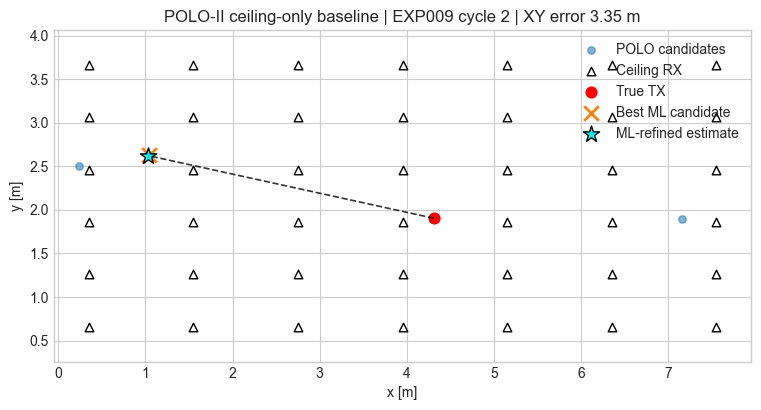

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

candidates = result["candidates"]
if candidates.size:
    ax.scatter(candidates[:, 0], candidates[:, 1], s=28, c="tab:blue", alpha=0.55, label="POLO candidates")

ax.scatter(antenna_xyz[:, 0], antenna_xyz[:, 1], marker="^", s=38, c="white", edgecolors="black", label="RX antennas")
ax.scatter([tx_x_true], [tx_y_true], marker="o", s=95, c="red", edgecolors="white", label="True TX")
ax.scatter([result["u0"][0]], [result["u0"][1]], marker="x", s=110, c="tab:orange", linewidths=2.0, label="Best ML candidate")
ax.scatter([tx_x_est], [tx_y_est], marker="*", s=150, c="cyan", edgecolors="black", label="ML-refined estimate")
ax.plot([tx_x_true, tx_x_est], [tx_y_true, tx_y_est], "k--", lw=1.2, alpha=0.8)

ax.set_xlim(bounds_xy[0])
ax.set_ylim(bounds_xy[1])
ax.set_title(f"{result['variant']} baseline | {EXPERIMENT_ID} cycle {SELECTED_CYCLE_ID} | XY error {xy_error_m:.2f} m")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right")
plt.show()

In [ ]:
eval_cycles = available_cycles.copy()
if USE_REFERENCE_CALIBRATION and reference_calibration_cycle_id is not None:
    eval_cycles = eval_cycles[eval_cycles != int(reference_calibration_cycle_id)]
eval_cycles = eval_cycles[: int(min(EVAL_NUM_CYCLES, eval_cycles.size))]
if eval_cycles.size == 0:
    raise ValueError("No evaluation cycles left after applying calibration-cycle exclusion.")

errors = []
pre_refine_errors = []
coverage_errors = []
candidate_counts = []
runtimes_s = []
true_xy = []
est_xy = []
used_cycles = []
failures = []

for cycle_id in eval_cycles:
    cycle_id = int(cycle_id)
    pos = csi.cycle_position(ds, EXPERIMENT_ID, cycle_id)
    try:
        _, antenna_xyz_i, y_i, hostnames_i = build_cycle_measurement(ds, EXPERIMENT_ID, cycle_id, antenna_positions)
        y_i_used, _ = apply_reference_calibration(y_i, hostnames_i, reference_calibration)
        result_i = run_polo_snapshot(
            y=y_i_used,
            antenna_xyz=antenna_xyz_i,
            tx_z_m=TX_HEIGHT_M,
            wavelength_m=wavelength_m,
            bounds_xy=bounds_xy,
            variant=POLO_VARIANT,
        )

        gt_xy = np.array([float(pos["rover_x"]), float(pos["rover_y"])], dtype=float)
        est = result_i["u_refined"]
        err = float(np.linalg.norm(est - gt_xy))
        pre_err = float(np.linalg.norm(result_i["u0"] - gt_xy))
        cov_err = float(np.min(np.linalg.norm(result_i["candidates"] - gt_xy[None, :], axis=1)))

        used_cycles.append(cycle_id)
        errors.append(err)
        pre_refine_errors.append(pre_err)
        coverage_errors.append(cov_err)
        candidate_counts.append(result_i["candidate_count"])
        runtimes_s.append(result_i["total_time_s"])
        true_xy.append(tuple(gt_xy))
        est_xy.append(tuple(est))
    except Exception as exc:
        failures.append((cycle_id, repr(exc)))

errors = np.asarray(errors, dtype=float)
pre_refine_errors = np.asarray(pre_refine_errors, dtype=float)
coverage_errors = np.asarray(coverage_errors, dtype=float)
candidate_counts = np.asarray(candidate_counts, dtype=float)
runtimes_s = np.asarray(runtimes_s, dtype=float)

print(f"Requested evaluation cycles: {len(eval_cycles)}")
print(f"Successful cycles: {len(used_cycles)} | failures: {len(failures)}")
if len(errors):
    print(f"Median XY error:            {np.median(errors):.3f} m")
    print(f"Mean XY error:              {np.mean(errors):.3f} m")
    print(f"P90 XY error:               {np.quantile(errors, 0.90):.3f} m")
    print(f"Min/Max error:              {errors.min():.3f} / {errors.max():.3f} m")
    print(f"Median candidate coverage:  {np.median(coverage_errors):.3f} m")
    print(f"Median candidate count:     {np.median(candidate_counts):.0f}")
    print(f"Median runtime:             {np.median(runtimes_s):.2f} s")
if failures[:5]:
    print("First failures:")
    for failure in failures[:5]:
        print(f"  cycle {failure[0]}: {failure[1]}")

Requested evaluation cycles: 5
Successful cycles: 5 | failures: 0
Median XY error:            3.351 m
Mean XY error:              3.340 m
P90 XY error:               3.991 m
Min/Max error:              2.365 / 4.084 m
Median candidate coverage:  2.709 m
Median candidate count:     2
Median runtime:             7.10 s


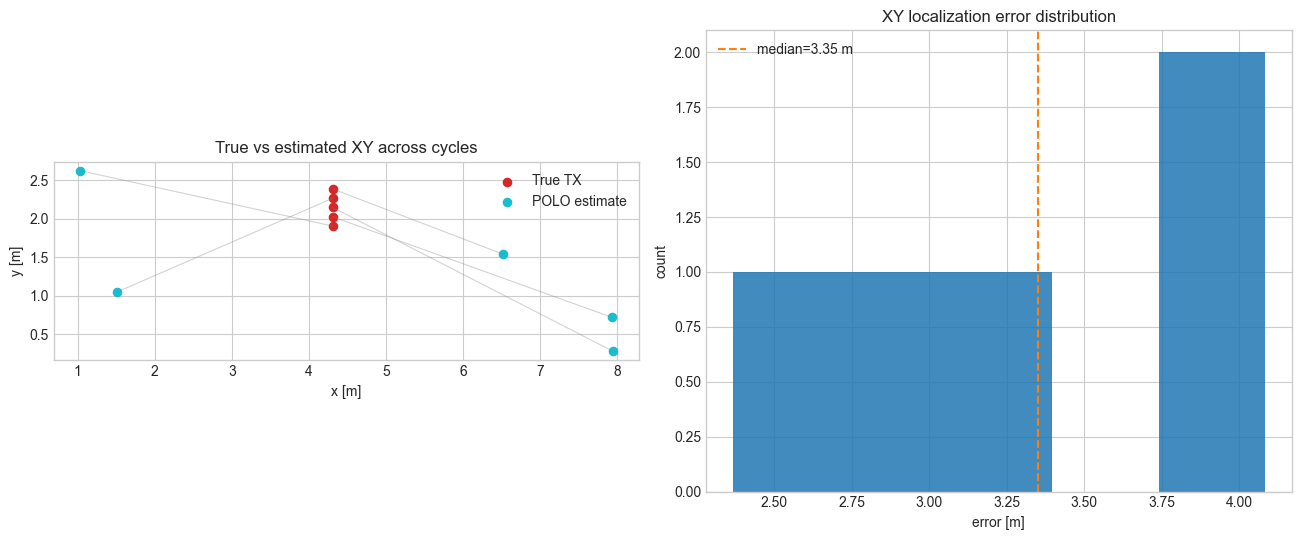

In [ ]:
if len(errors):
    true_xy_arr = np.asarray(true_xy, dtype=float)
    est_xy_arr = np.asarray(est_xy, dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    axes[0].scatter(true_xy_arr[:, 0], true_xy_arr[:, 1], c="tab:red", s=35, label="True TX")
    axes[0].scatter(est_xy_arr[:, 0], est_xy_arr[:, 1], c="tab:cyan", s=35, label="POLO estimate")
    for i in range(len(used_cycles)):
        axes[0].plot(
            [true_xy_arr[i, 0], est_xy_arr[i, 0]],
            [true_xy_arr[i, 1], est_xy_arr[i, 1]],
            color="gray",
            alpha=0.35,
            lw=0.8,
        )
    axes[0].set_title("True vs estimated XY across cycles")
    axes[0].set_xlabel("x [m]")
    axes[0].set_ylabel("y [m]")
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].legend()

    axes[1].hist(errors, bins=min(20, len(errors)), color="tab:blue", alpha=0.85)
    axes[1].axvline(np.median(errors), color="tab:orange", linestyle="--", label=f"median={np.median(errors):.2f} m")
    axes[1].set_title("XY localization error distribution")
    axes[1].set_xlabel("error [m]")
    axes[1].set_ylabel("count")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Notes

- `KNOW_MEASUREMENT_AREA=True` constrains POLO to the configured physical measurement-area rectangle; this is not derived from the cycle positions.
- `KNOW_MEASUREMENT_AREA=False` avoids TX trajectory leakage and uses a receiver-layout envelope plus `GRID_MARGIN_M` as a conservative fallback.
- The POLO-I and POLO-II candidate solvers use bounded nonlinear least-squares because receiver coordinates are 3D while the unknown transmitter is constrained to a known-height 2D plane.
- `POLO_II_REFINE_ALL_RAW_CANDIDATES=True` follows the note's debugging option: every raw POLO-II candidate is refined by the Step-2 least-squares problem. If you report runtime profile as exact POLO-II, replace this with a high-error-region mask.
- The final candidate selection and local refinement both use the compressed raw-IQ ML cost from the LaTeX note.
